# Development 5b: metrics for one block (CPU)

Scores the saved predictions against LiDAR ground truth, per scene, then
aggregates over scenes. **CPU server.** About 8 min of download, then roughly
half a minute per scene.

**Before the first run:** write your predictions into `docs/predictions.md` on the
laptop, then set `PREDICTIONS_REGISTERED = True` in cell 1. The notebook
refuses to score anything until you do. That gate is the whole point of
registering predictions: once the numbers are seen, they cannot be unseen.

In [1]:
# --- 1. Configuration ---
PREDICTIONS_REGISTERED = True     # set True only AFTER docs/predictions.md is filled in
PERSIST_MODE = "drive"
SPLIT, BLOCK = "val", 11
LAYERS = ["camera_keyframes", "lidar_motion_compensated_keyframes"]
CAMERA = "front_medium"
RUN_TAG = "phase5_val11_front_medium"

In [ ]:
# === CODE SYNC (auto-generated by `python -m vggt_aura.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m vggt_aura.sync   and reopen this notebook.")

In [3]:
# --- 3. The gate, then the session ---
if not PREDICTIONS_REGISTERED:
    raise RuntimeError("Fill in docs/predictions.md first, then set PREDICTIONS_REGISTERED = True in cell 1.")

from vggt_aura.session import start_session

session = start_session(persist_mode=PERSIST_MODE, require_gpu=False)

Mounted at /content/drive
installing vggt_omega
installing pybind11
installing fzi_aura
persist root: /content/drive/MyDrive/vggt-omega-aura-benchmark
data root   : /content/data/fzi-aura (runtime disk, wiped at session end)


In [4]:
# --- 4. Camera AND LiDAR layers of the block ---
import time
from vggt_aura import (aura_data as ad, evaluation as ev, geometry as geo, ground_truth as gtm,
                       inference as inf, metrics as mt, objects as ob, pins)

chunks, scene_blocks, hub_files = ad.fetch_release_tables(session.data_root / "_release_tables")
BLOCK_SCENE_IDS = ad.block_scene_ids(scene_blocks, SPLIT, BLOCK)
if ad.block_on_disk(session.data_root, BLOCK_SCENE_IDS, LAYERS):
    print("block already on disk with", LAYERS)
else:
    started = time.time()
    ad.download_block(session.data_root, SPLIT, BLOCK, BLOCK_SCENE_IDS, LAYERS)
    print(f"download and extract took {(time.time() - started) / 60:.1f} min")

$ /usr/bin/python3 -m fzi_aura.download /content/data/fzi-aura --revision 3404bd6b8fcd6eed53a0ec7610650a6393aabb49 --splits val --scene-ids-file /content/data/fzi-aura/_scene_ids_val_block000011.txt --layers camera_keyframes,lidar_motion_compensated_keyframes --jobs 8 --verify
download and extract took 11.7 min


In [5]:
# --- 5. Score every scene that has predictions ---
import json
import numpy as np
import pandas as pd
from fzi_aura import FZIAURADataset

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
CHECKPOINT = pins.CHECKPOINT_PUBLIC_512
dataset = FZIAURADataset(session.data_root, split=SPLIT)
PARAMS = {"two_sided": gtm.OcclusionParams(mode="two_sided"), "none": gtm.OcclusionParams(mode="none")}
all_rows, all_rows_no_occlusion, scene_records, timing = [], [], [], []

for scene_id in BLOCK_SCENE_IDS:
    scene = dataset.get_scene(scene_id)
    npz_path, json_path = inf.prediction_paths(session.persist_root, scene.name, CAMERA, CHECKPOINT)
    if not npz_path.is_file():
        print("no predictions for", scene_id, "- run notebook `05a_one_block_predict` first; scene skipped")
        continue
    started = time.time()
    arrays, _ = inf.load_predictions(npz_path, json_path)
    frames = inf.select_frames(scene, CAMERA)
    assert [f.timestamp_ns for f in frames] == arrays["timestamps_ns"].tolist(), "frames differ from the predicted ones"
    height, width = (int(v) for v in arrays["input_hw"])

    calibration = scene.calibration()
    P = calibration.camera_projection_matrix(CAMERA)
    native = calibration.sensor(f"camera/{CAMERA}")["intrinsics"]
    K = geo.scale_intrinsics(P[0, 0], P[1, 1], P[0, 2], P[1, 2], (native["width"], native["height"]), (width, height))
    classes = json.loads((scene.path / "labels" / "semantic" / "classes.json").read_text(encoding="utf-8"))
    class_names = {int(c["id"]): c["name"] for c in classes["semantic_classes"]}
    drop_ids = gtm.excluded_class_ids(class_names)
    lidars = list(scene.available_lidars())

    for mode, params in PARAMS.items():
        truth = gtm.build_scene_truth(frames, CAMERA, lidars, K, width, height, params, drop_ids)
        labels = ob.scene_motion_labels(frames, CAMERA, truth)
        rows, record = ev.evaluate_scene(scene_id, arrays, truth, labels, class_names, K[0], K[1])
        if mode == "two_sided":
            all_rows.append(rows)
            scene_records.append({**record, **{k: v for k, v in ad.scene_summary(scene).items()
                                               if k in ("road_type", "weather", "weather_group", "lighting", "speed_band",
                                                        "speed_kph_median", "sunrise_raw", "sunset_raw", "start_hour_utc")}})
            truth_npz, truth_json = gtm.truth_paths(session.persist_root, scene.name, CAMERA)
            gtm.save_scene_truth(truth_npz, truth_json, truth, [f.timestamp_ns for f in frames],
                                 {"scene_id": scene_id, "camera": CAMERA, "lidars": lidars, "model_wh": [width, height],
                                  "occlusion": params.as_dict(), "dataset_revision": pins.AURA_DATASET_REVISION})
        else:
            all_rows_no_occlusion.append(rows)
    timing.append(time.time() - started)
    print(f"{scene_id:26} {len(frames)} frames  {timing[-1]:5.1f} s")

rows = pd.concat(all_rows, ignore_index=True)
rows_no_occlusion = pd.concat(all_rows_no_occlusion, ignore_index=True)
scenes = pd.DataFrame(scene_records)
print()
print(f"scored {len(scenes)} scenes, median {np.median(timing):.0f} s per scene")

2025-07-15-13-11-47|24     40 frames   55.1 s
2025-06-11-13-47-25|25     40 frames   43.8 s
2025-06-13-07-09-37|78     40 frames   42.8 s
2025-07-15-14-15-47|71     40 frames   51.1 s
2025-07-15-13-11-47|63     40 frames   52.8 s
2025-06-11-12-27-55|207    40 frames   36.0 s
2025-07-15-13-11-47|110    40 frames   50.0 s
2025-06-16-12-35-26|82     39 frames   52.7 s
2025-06-16-12-35-26|2      40 frames   50.8 s
2025-07-15-13-11-47|10     40 frames   56.0 s
2025-07-15-13-11-47|48     40 frames   63.5 s
2025-06-11-13-47-25|24     40 frames   43.7 s
2025-06-11-12-27-55|211    40 frames   43.9 s
2025-06-16-12-35-26|73     40 frames   56.4 s
2025-07-15-14-15-47|59     40 frames   51.3 s
2025-07-15-13-11-47|74     40 frames   50.8 s
2025-06-12-08-12-52|38     40 frames   44.1 s
2025-06-16-13-29-59|6      40 frames   50.0 s
2025-07-15-14-15-47|46     40 frames   55.2 s
2025-06-13-07-09-37|39     40 frames   38.6 s

scored 20 scenes, median 51 s per scene


In [6]:
# --- 6. Save everything the tables are built from ---
out_dir = session.persist_root / "metrics" / RUN_TAG
out_dir.mkdir(parents=True, exist_ok=True)
rows.to_csv(out_dir / "depth_rows.csv", index=False)
rows_no_occlusion.to_csv(out_dir / "depth_rows_no_occlusion_handling.csv", index=False)
scenes.to_csv(out_dir / "scenes.csv", index=False)
ad.save_json(out_dir / "run.json", {
    "run_tag": RUN_TAG, "split": SPLIT, "block": BLOCK, "camera": CAMERA, "checkpoint": CHECKPOINT,
    "dataset_revision": pins.AURA_DATASET_REVISION, "model_code_commit": pins.VGGT_OMEGA_COMMIT,
    "protocols": mt.PROTOCOLS, "primary_protocol": mt.PRIMARY_PROTOCOL, "depth_range_m": [mt.DEPTH_MIN_M, mt.DEPTH_MAX_M],
    "occlusion": PARAMS["two_sided"].as_dict(), "moving_speed_mps": ob.MOVING_SPEED_MPS, "parked_speed_mps": ob.PARKED_SPEED_MPS,
    "min_pixels_per_stratum": ev.MIN_PIXELS_PER_STRATUM, "min_scenes": ev.DEFAULT_MIN_SCENES, "scenes": len(scenes)})
for scene_id in scenes["scene_id"]:
    if not session.manifest.is_done(scene_id, f"metrics/{RUN_TAG}"):
        session.manifest.mark_done(scene_id, f"metrics/{RUN_TAG}")
print("saved to", out_dir)

saved to /content/drive/MyDrive/vggt-omega-aura-benchmark/metrics/phase5_val11_front_medium


## Results

Every mean is a mean over SCENES, with a 95% bootstrap interval over scenes.
`thin = True` means fewer than 5 scenes support that row: read it as a
description of those scenes, not as a finding.

In [7]:
# --- 7. Depth: every protocol, then the strata under the primary protocol ---
report = ev.build_report(rows, scenes)


def show(title, table, digits=4):
    print()
    print("=====", title, "=====")
    print(table.round(digits).to_string(index=False) if len(table) else "(no rows)")


show("AbsRel by alignment protocol (all pixels)", report["headline_by_protocol"])
show("moving vs parked vs background pixels  [sequence_scale]", report["motion"])
show("paired differences within scenes (a minus b; positive = a is worse)", report["moving_vs_background"])
show("by ground-truth depth  [sequence_scale]", report["depth_band"])
show("by semantic group  [sequence_scale]", report["semantic_group"])
show("by the model's own confidence  [sequence_scale]", report["confidence_quartile"])


===== AbsRel by alignment protocol (all pixels) =====
         protocol  n_scenes   pixels  abs_rel  ci_low  ci_high  thin  delta125
      frame_scale        20 37520445   0.0494  0.0426   0.0566 False    0.9696
frame_scale_shift        20 37520445   0.0521  0.0443   0.0602 False    0.9690
       pose_scale        20 37520445   0.0562  0.0496   0.0630 False    0.9688
   sequence_scale        20 37520445   0.0542  0.0475   0.0610 False    0.9691
        unaligned        20 37520445   0.9798  0.9758   0.9837 False    0.0000

===== moving vs parked vs background pixels  [sequence_scale] =====
         stratum  n_scenes   pixels  abs_rel  ci_low  ci_high  thin  delta125
      background        20 34740718   0.0499  0.0442   0.0557 False    0.9711
   moving object        17   357942   0.1754  0.1228   0.2527 False    0.8716
   parked object        18  2317121   0.0836  0.0583   0.1132 False    0.9630
uncertain object        14   104265   0.1337  0.1046   0.1690 False    0.9081

===== paire

In [8]:
# --- 8. Pose, intrinsics, scale agreement, and the trap-3 bound on moving-object ground truth ---
show("camera pose (scenes that actually move)", report["pose_moving_scenes_only"])
print("near-stationary scenes kept out of the pose table:", int(scenes["near_stationary"].sum()), "of", len(scenes))
show("focal length error, depth/pose scale agreement, moving-object ground-truth bound", report["intrinsics_scale_and_trap3"])
print()
print("fx_rel_err < 0 means the predicted focal length is too SHORT.")
print("pose_scale_over_depth_scale = 1 means depth and camera translation agree on the scale.")
print("moving_gt_bound_rel is how wrong the LiDAR depth of a moving object can itself be (trap 3), as a share of its depth.")
print("Compare it with the moving-object AbsRel above before reading anything into that number.")


===== camera pose (scenes that actually move) =====
                    metric  n_scenes    mean  ci_low  ci_high
       rotation_deg_median        20  0.5528  0.3236   0.8965
    translation_deg_median        20  0.8018  0.7049   0.9340
                      auc3        20 83.9726 75.1937  90.7469
                     auc30        20 98.1942 97.0000  99.0307
    auc30_authors_unsigned        20 98.1942 97.0000  99.0307
          ate_scale_only_m        20  1.6816  0.7026   3.3784
ate_scale_only_pct_of_path        20  1.0394  0.8092   1.3871
                ate_sim3_m        20  0.5365  0.2303   1.0005
near-stationary scenes kept out of the pose table: 0 of 20

===== focal length error, depth/pose scale agreement, moving-object ground-truth bound =====
                     metric  n_scenes    mean  ci_low  ci_high
          fx_rel_err_median        20 -0.0332 -0.0614  -0.0099
          fy_rel_err_median        20 -0.0778 -0.1046  -0.0550
              fx_spread_rel        20  0.0330  

In [9]:
# --- 9. Scene-level strata, and how much the occlusion rule matters ---
for attribute in ev.SCENE_ATTRIBUTES:
    show(f"AbsRel by {attribute}  [sequence_scale, scene level]", report[f"by_{attribute}"])
print()
print("sunrise / sunset raw values (first scene):", scenes.loc[0, "sunrise_raw"], scenes.loc[0, "sunset_raw"])

no_occlusion = ev.build_report(rows_no_occlusion, scenes)
compare = report["motion"][["stratum", "n_scenes", "abs_rel"]].merge(
    no_occlusion["motion"][["stratum", "abs_rel"]], on="stratum", suffixes=("_two_sided", "_no_occlusion_handling"))
show("sensitivity to the occlusion rule  [sequence_scale]", compare)


===== AbsRel by road_type  [sequence_scale, scene level] =====
road_type  n_scenes  abs_rel  ci_low  ci_high  thin
 overland         2   0.0676  0.0607   0.0745  True
    urban        18   0.0527  0.0456   0.0596 False

===== AbsRel by weather_group  [sequence_scale, scene level] =====
weather_group  n_scenes  abs_rel  ci_low  ci_high  thin
          dry        17   0.0557  0.0486   0.0632 False
          wet         3   0.0453  0.0319   0.0522  True

===== AbsRel by lighting  [sequence_scale, scene level] =====
lighting  n_scenes  abs_rel  ci_low  ci_high  thin
     day        20   0.0542  0.0475    0.061 False

===== AbsRel by speed_band  [sequence_scale, scene level] =====
  speed_band  n_scenes  abs_rel  ci_low  ci_high  thin
  20-50 km/h         8   0.0532  0.0466   0.0601 False
   5-20 km/h         6   0.0545  0.0397   0.0703 False
over 50 km/h         2   0.0676  0.0607   0.0745  True
under 5 km/h         4   0.0489  0.0355   0.0665  True

sunrise / sunset raw values (first sce

In [10]:
# --- 10. Per-scene table, worst first ---
primary = rows[(rows["protocol"] == mt.PRIMARY_PROTOCOL) & (rows["stratum_type"] == "all")][["scene_id", "abs_rel", "delta125", "n_pixels"]]
per_scene = primary.merge(scenes[["scene_id", "road_type", "weather_group", "speed_kph_median", "gt_path_m", "near_stationary",
                                  "auc30", "ate_scale_only_pct_of_path", "fx_rel_err_median", "pose_scale_over_depth_scale",
                                  "moving_pixels"]], on="scene_id").sort_values("abs_rel", ascending=False)
print(per_scene.round(3).to_string(index=False))
per_scene.to_csv(out_dir / "per_scene.csv", index=False)

               scene_id  abs_rel  delta125  n_pixels road_type weather_group  speed_kph_median  gt_path_m  near_stationary  auc30  ate_scale_only_pct_of_path  fx_rel_err_median  pose_scale_over_depth_scale  moving_pixels
2025-06-11-12-27-55|207    0.089     0.952   1249823     urban           dry             9.680     79.870            False 99.534                       1.294             -0.068                        0.990          15011
 2025-06-11-13-47-25|25    0.077     0.954   1492753     urban           dry             3.965     38.329            False 99.339                       1.166             -0.076                        1.001          26963
 2025-06-12-08-12-52|38    0.075     0.952   1619807  overland           dry            76.340    418.672            False 89.709                       3.851             -0.196                        0.993          53040
 2025-06-13-07-09-37|78    0.070     0.955   1675460     urban           dry            30.550    166.214           

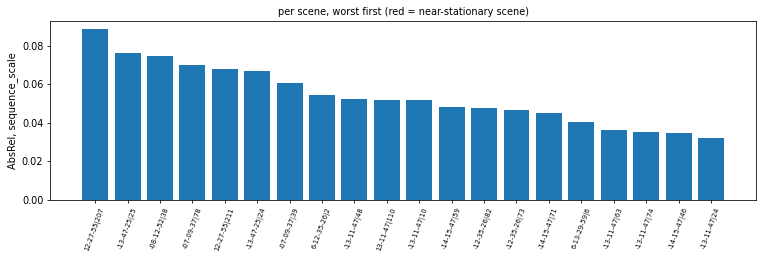

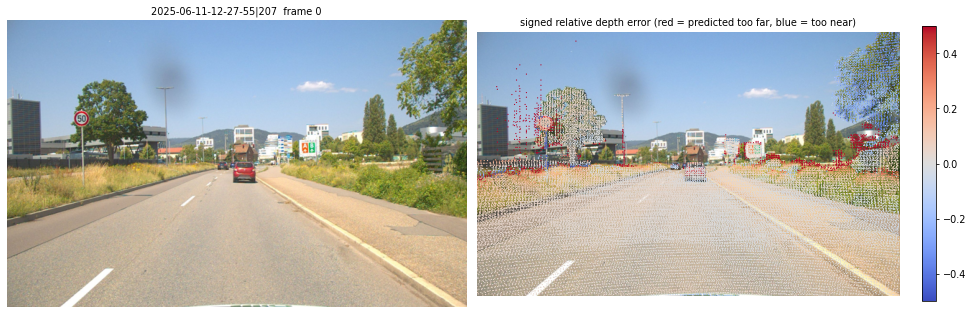

worst scene: 2025-06-11-12-27-55|207 | worst frame: 0 | that frame's AbsRel: 0.176


In [11]:
# --- 11. Figures: per-scene error, and an error map of the worst frame of the worst scene ---
import matplotlib.pyplot as plt
from PIL import Image

figure_dir = session.persist_root / "figures" / "phase5"
figure_dir.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(11, 3.8), dpi=70)
colours = ["tab:red" if flag else "tab:blue" for flag in per_scene["near_stationary"]]
axis.bar(range(len(per_scene)), per_scene["abs_rel"], color=colours)
axis.set_xticks(range(len(per_scene)))
axis.set_xticklabels([s[-12:] for s in per_scene["scene_id"]], rotation=70, fontsize=7)
axis.set_ylabel("AbsRel, sequence_scale")
axis.set_title("per scene, worst first (red = near-stationary scene)", fontsize=10)
figure.tight_layout()
figure.savefig(figure_dir / f"{RUN_TAG}_per_scene.png", dpi=70)
plt.show()

worst_id = per_scene.iloc[0]["scene_id"]
scene = dataset.get_scene(worst_id)
arrays, _ = inf.load_predictions(*inf.prediction_paths(session.persist_root, scene.name, CAMERA, CHECKPOINT))
truth, _, _ = gtm.load_scene_truth(*gtm.truth_paths(session.persist_root, scene.name, CAMERA))
frames = inf.select_frames(scene, CAMERA)
pred_all = np.concatenate([arrays["depth"][i, t["v"].astype(int), t["u"].astype(int)] for i, t in enumerate(truth)])
gt_all = np.concatenate([t["depth_m"] for t in truth])
keep_all = (gt_all >= mt.DEPTH_MIN_M) & (gt_all <= mt.DEPTH_MAX_M)
scale = mt.median_scale(pred_all[keep_all], gt_all[keep_all])
errors = []
for i, t in enumerate(truth):
    keep = (t["depth_m"] >= mt.DEPTH_MIN_M) & (t["depth_m"] <= mt.DEPTH_MAX_M)
    pred = arrays["depth"][i, t["v"].astype(int), t["u"].astype(int)] * scale
    errors.append(np.mean(np.abs(pred[keep] - t["depth_m"][keep]) / t["depth_m"][keep]) if keep.any() else np.nan)
worst_frame = int(np.nanargmax(errors))
t = truth[worst_frame]
keep = (t["depth_m"] >= mt.DEPTH_MIN_M) & (t["depth_m"] <= mt.DEPTH_MAX_M)
signed = (arrays["depth"][worst_frame, t["v"].astype(int), t["u"].astype(int)] * scale - t["depth_m"]) / t["depth_m"]
height, width = (int(v) for v in arrays["input_hw"])
image = np.asarray(Image.open(frames[worst_frame].camera_path(CAMERA)).convert("RGB").resize((width, height)))
figure, axes = plt.subplots(1, 2, figsize=(14, 4.6), dpi=70)
axes[0].imshow(image); axes[0].set_title(f"{worst_id}  frame {worst_frame}", fontsize=10)
axes[1].imshow(image)
points = axes[1].scatter(t["u"][keep], t["v"][keep], c=np.clip(signed[keep], -0.5, 0.5), cmap="coolwarm", s=1.5, linewidths=0)
axes[1].set_title("signed relative depth error (red = predicted too far, blue = too near)", fontsize=10)
figure.colorbar(points, ax=axes[1], fraction=0.03)
for axis in axes:
    axis.axis("off")
figure.tight_layout()
figure.savefig(figure_dir / f"{RUN_TAG}_worst_frame.png", dpi=70)
plt.show()
print("worst scene:", worst_id, "| worst frame:", worst_frame, "| that frame's AbsRel: %.3f" % errors[worst_frame])